In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from math import factorial
import scipy.integrate as integrate

# Q2

In [2]:
def beta(a,b,theta):
    '''
    The prior is the beta distribution function. a = heads, b = tails, theta = θ is the probability of getting a head
    '''
    coeff = factorial(a + b - 1)/(factorial(a - 1)*factorial(b - 1))
    return coeff*theta**(a - 1)*(1 - theta)**(b - 1)

def binomial(n,h,theta):
    '''
    The likelihood function is the binomial distribution. n = total number of coin flips, h is the number of heads, theta is the probability
    of getting a head. 
    '''
    denom = factorial(h)*factorial(n-h)
    return factorial(n)/denom * theta**h * (1 - theta)**(n - h)

def make_prior(a, b):
    '''
    The prior function, since theta needs to be swept (not a direct input), I'm defining the "main" function inside 
    '''
    def prior(theta):
        return beta(a,b,theta)
    return prior

def make_likelihood(n, h):
    '''
    The likelihood function, since theta needs to be swept (not a direct input), I'm defining the "main" function inside 
    '''
    def likelihood(theta):
        return binomial(n,h,theta)
    return likelihood

def make_posterior(prior, likelihood):

    def unnormalized(theta):
        return prior(theta) * likelihood(theta)

    normalization, _ = integrate.quad(unnormalized, 0, 1) #returns (value, error) - only need value

    def posterior(theta):
        return unnormalized(theta) / normalization
    return posterior


def Bayes(dataname,a,b):
    '''
    This is the function asked for in Q2a since it outputs the posterior probability distribution function.
    '''
    if isinstance(dataname, str):
        data = np.loadtxt(dataname)
    else:
        data = dataname
    
    n = len(data) #number of coin flips
    h = int(np.sum(data)) #number of heads, so 0 = tails, 1 = heads (want to add up all the heads)

    likelihood = make_likelihood(n, h)
    prior = make_prior(a, b) 
    posterior = make_posterior(prior, likelihood)

    return posterior

## Part b

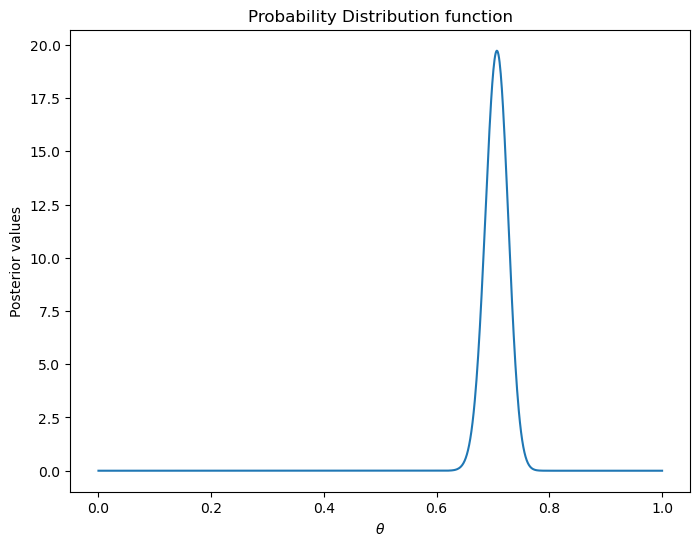

In [6]:
posterior = Bayes("HW06_data.txt",2,5)

thetas = np.linspace(0,1,1000) #test over different values of theta
p_vals = np.array([posterior(t) for t in thetas])

plt.figure(figsize=(8,6))
plt.plot(thetas,p_vals)
plt.xlabel(r"$\theta$")
plt.ylabel("Posterior values")
plt.title("Probability Distribution function")
plt.savefig("pdf.png",dpi=300)
plt.show()

## Part c

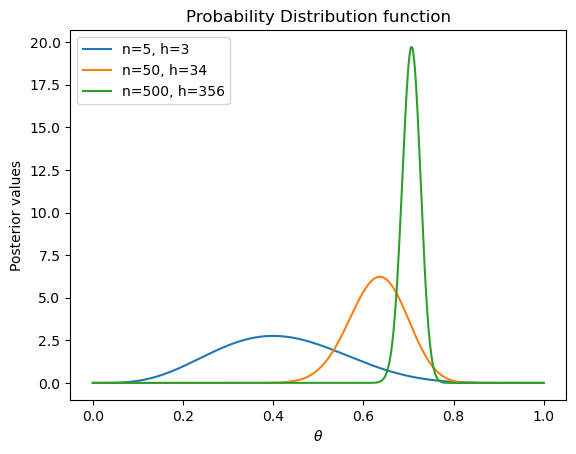

In [7]:
data = np.loadtxt("HW06_data.txt")
n = [5,50,500]
prior = make_prior(2, 5) 
thetas = np.linspace(0,1,1000) #test over different values of theta

for coin_flips in n:
    h = int(np.sum(data[:coin_flips]))
    likelihood = make_likelihood(coin_flips, h)
    posterior = make_posterior(prior, likelihood)
    p_vals = np.array([posterior(t) for t in thetas])

    plt.plot(thetas, p_vals, label=f"n={coin_flips}, h={h}")

plt.xlabel(r"$\theta$")
plt.ylabel("Posterior values")
plt.title("Probability Distribution function")
plt.legend()
plt.savefig("pdf_mn.png",dpi=300)
plt.show()

## Part d

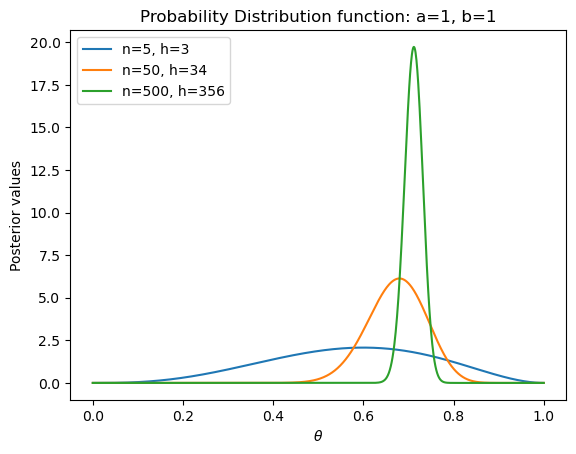

In [28]:
data = np.loadtxt("HW06_data.txt")
n = [5,50,500]
h = int(np.sum(data)) #number of heads, so 0 = tails, 1 = heads (want to add up all the heads)
a, b = 1, 1
prior = make_prior(a, b) #flat - no idea if coin is fair
thetas = np.linspace(0,1,1000) #test over different values of theta

for coin_flips in n:
    h = int(np.sum(data[:coin_flips]))
    likelihood = make_likelihood(coin_flips, h)
    posterior = make_posterior(prior, likelihood)
    p_vals = np.array([posterior(t) for t in thetas])

    plt.plot(thetas, p_vals, label=f"n={coin_flips}, h={h}")

plt.xlabel(r"$\theta$")
plt.ylabel("Posterior values")
plt.title(f"Probability Distribution function: a={a}, b={b}")
plt.legend()
plt.savefig("pdf_11.png",dpi=300)
plt.show()

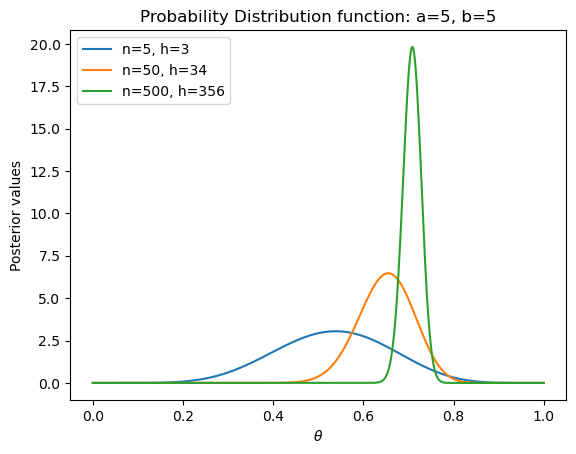

In [29]:
data = np.loadtxt("HW06_data.txt")
n = [5,50,500]
h = int(np.sum(data)) #number of heads, so 0 = tails, 1 = heads (want to add up all the heads)
a, b = 5,5
prior = make_prior(a, b) #roughly fair coin
thetas = np.linspace(0,1,1000) #test over different values of theta

for coin_flips in n:
    h = int(np.sum(data[:coin_flips]))
    likelihood = make_likelihood(coin_flips, h)
    posterior = make_posterior(prior, likelihood)
    p_vals = np.array([posterior(t) for t in thetas])

    plt.plot(thetas, p_vals, label=f"n={coin_flips}, h={h}")

plt.xlabel(r"$\theta$")
plt.ylabel("Posterior values")
plt.title(f"Probability Distribution function: a={a}, b={b}")
plt.legend()
plt.savefig("pdf_55.png",dpi=300)
plt.show()

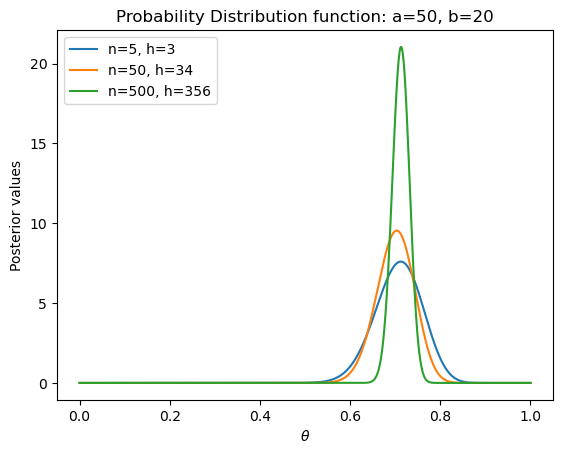

In [30]:
data = np.loadtxt("HW06_data.txt")
n = [5,50,500]
h = int(np.sum(data)) #number of heads, so 0 = tails, 1 = heads (want to add up all the heads)
a, b = 50, 20
prior = make_prior(a, b) #strong belief coin biased towards heads
thetas = np.linspace(0,1,1000) #test over different values of theta

for coin_flips in n:
    h = int(np.sum(data[:coin_flips]))
    likelihood = make_likelihood(coin_flips, h)
    posterior = make_posterior(prior, likelihood)
    p_vals = np.array([posterior(t) for t in thetas])

    plt.plot(thetas, p_vals, label=f"n={coin_flips}, h={h}")

plt.xlabel(r"$\theta$")
plt.ylabel("Posterior values")
plt.title(f"Probability Distribution function: a={a}, b={b}")
plt.legend()
plt.savefig("pdf_5020.png",dpi=300)
plt.show()

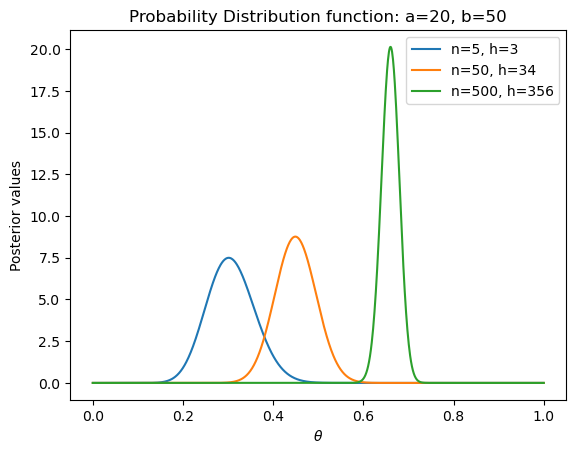

In [31]:
data = np.loadtxt("HW06_data.txt")
n = [5,50,500]
h = int(np.sum(data)) #number of heads, so 0 = tails, 1 = heads (want to add up all the heads)
a,b = 20,50
prior = make_prior(a, b) #strong belief coin biased towards tails
thetas = np.linspace(0,1,1000) #test over different values of theta

for coin_flips in n:
    h = int(np.sum(data[:coin_flips]))
    likelihood = make_likelihood(coin_flips, h)
    posterior = make_posterior(prior, likelihood)
    p_vals = np.array([posterior(t) for t in thetas])

    plt.plot(thetas, p_vals, label=f"n={coin_flips}, h={h}")

plt.xlabel(r"$\theta$")
plt.ylabel("Posterior values")
plt.title(f"Probability Distribution function: a={a}, b={b}")
plt.legend()
plt.savefig("pdf_2050.png",dpi=300)
plt.show()

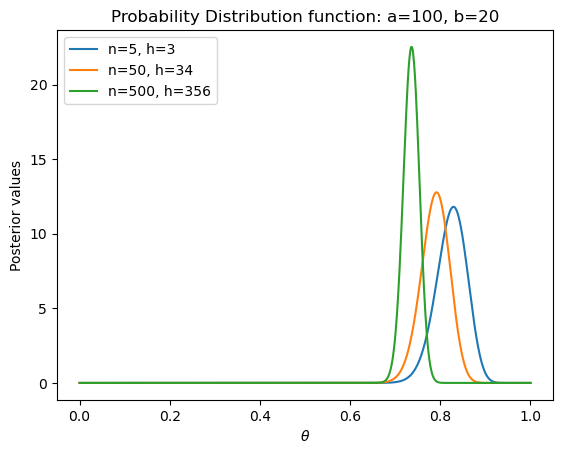

In [32]:
data = np.loadtxt("HW06_data.txt")
n = [5,50,500]
h = int(np.sum(data)) #number of heads, so 0 = tails, 1 = heads (want to add up all the heads)
a, b = 100,20
prior = make_prior(a, b) #weak belief in fairness - open to be wrong
thetas = np.linspace(0,1,1000) #test over different values of theta

for coin_flips in n:
    h = int(np.sum(data[:coin_flips]))
    likelihood = make_likelihood(coin_flips, h)
    posterior = make_posterior(prior, likelihood)
    p_vals = np.array([posterior(t) for t in thetas])

    plt.plot(thetas, p_vals, label=f"n={coin_flips}, h={h}")

plt.xlabel(r"$\theta$")
plt.ylabel("Posterior values")
plt.title(f"Probability Distribution function: a={a}, b={b}")
plt.legend()
plt.savefig("pdf_10020.png",dpi=300)
plt.show()

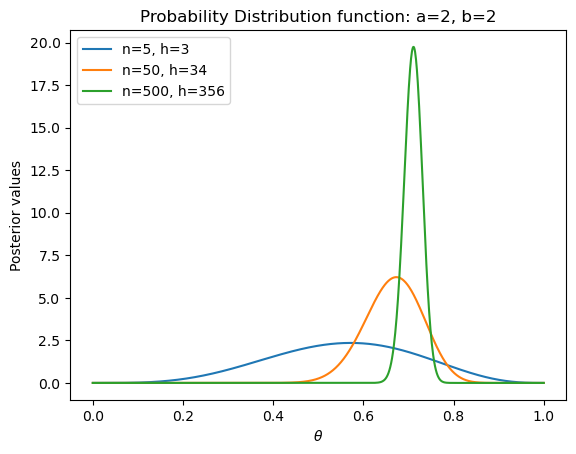

In [33]:
data = np.loadtxt("HW06_data.txt")
n = [5,50,500]
h = int(np.sum(data)) #number of heads, so 0 = tails, 1 = heads (want to add up all the heads)
a, b = 2,2
prior = make_prior(a, b) #weak belief in fairness - open to be wrong
thetas = np.linspace(0,1,1000) #test over different values of theta

for coin_flips in n:
    h = int(np.sum(data[:coin_flips]))
    likelihood = make_likelihood(coin_flips, h)
    posterior = make_posterior(prior, likelihood)
    p_vals = np.array([posterior(t) for t in thetas])

    plt.plot(thetas, p_vals, label=f"n={coin_flips}, h={h}")

plt.xlabel(r"$\theta$")
plt.ylabel("Posterior values")
plt.title(f"Probability Distribution function: a={a}, b={b}")
plt.legend()
plt.savefig("pdf_22.png",dpi=300)
plt.show()

# Q3

In [81]:
N = 500 #number of points
x = np.random.uniform(0, 1, N)
y = np.random.uniform(0, 1, N)

inside = (x**2+y**2) <= 1
h = np.sum(inside)
print(f"{h} points fall inside the circle")

posterior = Bayes(inside,2,2)
pi_hat = 4*integrate.quad(lambda t: t * posterior(t), 0, 1)[0]
print("My estimated value of pi =", pi_hat)
#print("True value of pi = ", np.pi)

rel_err = np.abs(pi_hat-np.pi)/np.pi * 100
print(f"Relative error between pi and pi_hat for n = {N} and priors a, b = {a,b} is {rel_err}")

391 points fall inside the circle
My estimated value of pi = 3.1190476190476186
Relative error between pi and pi_hat for n = 500 and priors a, b = (2, 2) is 0.7176307379129192


In [84]:
N = 1000 #number of points
x = np.random.uniform(0, 1, N)
y = np.random.uniform(0, 1, N)

inside = (x**2+y**2) <= 1
h = np.sum(inside)
print(f"{h} points fall inside the circle")

posterior = Bayes(inside,10,2)
pi_hat = 4*integrate.quad(lambda t: t * posterior(t), 0, 1)[0]
print("My estimated value of pi =", pi_hat)
#print("True value of pi = ", np.pi)

rel_err = np.abs(pi_hat-np.pi)/np.pi * 100
print(f"Relative error between pi and pi_hat for n = {N} and priors a, b = {a,b} is {rel_err}")

792 points fall inside the circle
My estimated value of pi = 3.169960474319978
Relative error between pi and pi_hat for n = 1000 and priors a, b = (2, 2) is 0.9029757787907352


In [85]:
N = 50 #number of points
x = np.random.uniform(0, 1, N)
y = np.random.uniform(0, 1, N)

inside = (x**2+y**2) <= 1
h = np.sum(inside)
print(f"{h} points fall inside the circle")

posterior = Bayes(inside,10,20)
pi_hat = 4*integrate.quad(lambda t: t * posterior(t), 0, 1)[0]
print("My estimated value of pi =", pi_hat)
#print("True value of pi = ", np.pi)

rel_err = np.abs(pi_hat-np.pi)/np.pi * 100
print(f"Relative error between pi and pi_hat for n = {N} and priors a, b = {a,b} is {rel_err}")

42 points fall inside the circle
My estimated value of pi = 2.599999999998197
Relative error between pi and pi_hat for n = 50 and priors a, b = (2, 2) is 17.23942959227181
